In [1]:
import os, sys
import itertools
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import root_mean_squared_error as rmse
parts=os.getcwd().split('/')
print(parts)
if (parts[-1]=='scripts') |(parts[-1]=='notebooks'):
    parts=parts[:-1]
common_path='/'.join(parts)
srcpath=common_path+'/results/'
out_path=srcpath+'metaanalysis/'
solver_type='sgd'
figpath=common_path+'/figures/'
#################  0 ######### 1 ######### 2 ######## 3 ###### 4 ########## 5
dname_all=['breastcancer', 'surgical', 'banking', 'adult', 'diabetes','criteo']
dname=dname_all[4]
exp_type, solver_type='random', 'sgd'
respath='%s%s/%s_random_enforced_unlearn_swish_%s_all.csv'%(srcpath,dname, dname,solver_type)
res_df=pd.read_csv(respath, sep='\t')
code_path='/'.join(parts)+'/scripts/'
sys.path.append(code_path)
from experiment_utils import dataset_health
modelpath='/'.join(parts)+'/models/'
from experiment_utils import data_norm_log
from unlearning.unlearn_eval import *
Xtrain, Ytrain, Xtest, Ytest, features=dataset_health(dname)
zXtrain, zXtest=data_norm_log(Xtrain, Xtest)
print(res_df['n_unlearn'].unique(), Xtrain.shape)
#zXtrain, zXtest=data_norm_log(Xtrain[features], Xtest[features])
res_df.rename(columns={'n_unlearn':'n_unlearned'}, inplace=True)
colnames=list(res_df.columns)
print(len(colnames))
exp_model_specs=[ 'iter','ppc']
model_perf_cols=['et_retrain', 'et_unlearn', 'n_retrain', 'n_unlearned', 'dev_M0M2','dev_M1M2',
               'tr_M0_Bacc', 'tr_M1_Bacc', 'tr_M2_Bacc', #'tr_M0_AUC', 'tr_M1_AUC',  'tr_M2_AUC',
               'tr_M0_nAcc', 'tr_M1_nAcc','tr_retain_corr_M1', 'tr_imp_corr_M1',  'tr_lost_preds_M1',
               'tr_M2_nAcc', 'tr_imp_corr_M2',  'tr_retain_corr_M2','tr_lost_preds_M2' ,
               'te_M0_Bacc', 'te_M1_Bacc', 'te_M2_Bacc', #'te_M0_AUC', 'te_M1_AUC',  'te_M2_AUC',
               'te_M0_nAcc', 'te_M1_nAcc','te_retain_corr_M1', 'te_imp_corr_M1', 'te_lost_preds_M1',
               'te_M2_nAcc', 'te_imp_corr_M2',  'te_retain_corr_M2','te_lost_preds_M2',
               'un_M0_nAcc', 'un_M1_nAcc','un_retain_corr_M1', 'un_imp_corr_M1', 'un_lost_preds_M1',
               'un_M2_nAcc', 'un_imp_corr_M2',  'un_retain_corr_M2','un_lost_preds_M2']
model_param_cols=['et_retrain', 'et_unlearn', 'n_retrain', 'n_unlearned', 
               'dev_M0M1', 'dev_M0M2', 'dev_M1M2' ]
res_df.head(3)
res_df_time=res_df[exp_model_specs+['et_retrain', 'et_unlearn', 'n_retrain', 'n_unlearned']]

['', 'mnt', 'nvme1n1p2', 'codes_datasets', 'toolboxes', 'unlearn-lvq', 'notebooks']
/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq
[   9.   82.  815. 8142.] (81412, 43)
54


In [2]:
models, subsets=['M1', 'M2'], ['tr', 'te', 'un']
res_df.replace([np.inf, -np.inf], np.nan,inplace=True)
sliced_df=res_df.copy()#[exp_model_specs+model_param_cols+model_perf_cols].copy()
eval_metrics, nan_counter=[],[]
for subset in subsets:
    if subset==subsets[0]:
        sliced_df['speedupX']=sliced_df['et_retrain'].to_numpy()/sliced_df['et_unlearn'].to_numpy()
        eval_metrics.append('speedupX')
        sliced_df['%s_Acc_M0'%(subset)]=sliced_df['%s_M0_nAcc'%(subset)]/sliced_df['n_retrain']  #'n_test'
        eval_metrics.append('%s_Acc_M0'%(subset))
        eval_metrics.append('dev_M0M2')
        eval_metrics.append('dev_M1M2')
    elif subset=='te':
        sliced_df['%s_Acc_M0'%(subset)]=sliced_df['%s_M0_nAcc'%(subset)]/sliced_df['n_test']  #'n_test'
        eval_metrics.append('%s_Acc_M0'%(subset))
    else:
        sliced_df['%s_Acc_M0'%(subset)]=sliced_df['%s_M0_nAcc'%(subset)]/sliced_df['n_unlearned']  #'n_test'
        eval_metrics.append('%s_Acc_M0'%(subset))
    for model in models:
        if subset=='tr':     
            N=sliced_df['n_retrain']
        elif subset=='te':
          #  sliced_df['%s_Acc_%s'%(subset, model)]=sliced_df['%s_%s_nAcc'%(subset, model)]/sliced_df['n_test']*100
            N=sliced_df['n_test']
        else:
           # sliced_df['%s_Acc_%s'%(subset, model)]=sliced_df['%s_%s_nAcc'%(subset, model)]/sliced_df['n_unlearned']*100
            N=sliced_df['n_unlearned']
        sliced_df['%s_Acc_%s'%(subset, model)]=sliced_df['%s_%s_nAcc'%(subset, model)]*100/N#sliced_df['n_retrain']*100
        eval_metrics.append('%s_Acc_%s'%(subset, model))
        if np.sum(sliced_df['%s_M0_nAcc'%subset]==0)==0:
            sliced_df['%s_retain_frac_%s'%(subset, model)]=sliced_df['%s_retain_corr_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
            sliced_df['%s_loss_frac_%s'%(subset, model)]=sliced_df['%s_lost_preds_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
            sliced_df['%s_gain_frac_%s'%(subset, model)]=sliced_df['%s_imp_corr_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
        else:   
            sliced_df['%s_retain_frac_%s'%(subset, model)]=sliced_df['%s_retain_corr_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
            sliced_df['%s_loss_frac_%s'%(subset, model)]=sliced_df['%s_lost_preds_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
            sliced_df['%s_gain_frac_%s'%(subset, model)]=sliced_df['%s_imp_corr_%s'%(subset, model)]/sliced_df['%s_M0_nAcc'%subset]*100
        #sliced_df['nan_%s_retain_frac_%s'%(subset, model)]=sliced_df['%s_retain_frac_%s'%(subset, model)].isnull()
        #sliced_df['nan_%s_loss_frac_%s'%(subset, model)]=sliced_df['%s_loss_frac_%s'%(subset, model)].isnull()
        #sliced_df['nan_%s_gain_frac_%s'%(subset, model)]=sliced_df['%s_gain_frac_%s'%(subset, model)].isnull()
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, 'nan_%s_retain_frac_%s'%(subset, model)]=1#np.nan
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, 'nan_%s_loss_frac_%s'%(subset, model)]=1##np.nan
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, 'nan_%s_gain_frac_%s'%(subset, model)]=1#np.nan
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, '%s_retain_frac_%s'%(subset, model)]=0#np.nan
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, '%s_loss_frac_%s'%(subset, model)]=0 #np.nan
        sliced_df.loc[sliced_df['%s_M0_nAcc'%(subset)]==0, '%s_gain_frac_%s'%(subset, model)]=np.nan
        eval_metrics.append('%s_retain_frac_%s'%(subset, model))
        eval_metrics.append('%s_loss_frac_%s'%(subset, model))
        eval_metrics.append('%s_gain_frac_%s'%(subset, model))
        nan_counter.append('%s_retain_frac_%s'%(subset, model))
        nan_counter.append('%s_loss_frac_%s'%(subset, model))
        nan_counter.append('%s_gain_frac_%s'%(subset, model))
eval_metrics=np.unique(eval_metrics)
nan_cols=np.array(['nan_'+ entry for entry in nan_counter])#nan_man_std=np.intersect1d
nan_res=sliced_df.groupby(['n_unlearned','ppc'])[nan_cols].sum().reset_index()
mean_res=sliced_df.groupby(['n_unlearned','ppc'])[eval_metrics].mean().reset_index()
std_res=sliced_df.groupby(['n_unlearned','ppc'])[eval_metrics].std().reset_index()
col_order=np.array(['n_unlearned', 'ppc', 'speedupX','dev_M0M2','dev_M1M2', 
           'tr_Acc_M0', 'tr_Acc_M1', 'tr_Acc_M2', 'tr_retain_frac_M1', 'tr_retain_frac_M2', 
           'tr_loss_frac_M1', 'tr_loss_frac_M2','tr_gain_frac_M1', 'tr_gain_frac_M2', 
           'te_Acc_M0','te_Acc_M1','te_Acc_M2', 'te_retain_frac_M1', 
           'te_retain_frac_M2','te_loss_frac_M1', 'te_loss_frac_M2', 'te_gain_frac_M1', 'te_gain_frac_M2',
           'un_Acc_M0','un_Acc_M1', 'un_Acc_M2', 'un_retain_frac_M1', 'un_retain_frac_M2',
           'un_loss_frac_M1', 'un_loss_frac_M2', 'un_gain_frac_M1', 'un_gain_frac_M2'])
mean_res=mean_res[col_order].copy()
mean_cols=['mean_'+ entry for entry in eval_metrics]
std_cols=['std_'+ entry for entry in eval_metrics]
mean_res.rename(columns=dict(zip(eval_metrics, mean_cols)), inplace=True)
std_res=std_res[col_order].copy()
std_res.rename(columns=dict(zip(eval_metrics, std_cols)), inplace=True)
common_cols=list(np.intersect1d(list(mean_res.columns), list(std_res.columns)))    
print(common_cols)
final_col_order=list(itertools.chain(*[ [mean_cols[i], std_cols[i]] for i in range(0, len(mean_cols))]))
combined=pd.concat([mean_res, std_res[std_cols]], axis=1)
combined=combined[common_cols+final_col_order]
for nan_col in nan_counter:
    comb_cols=['_'.join(x.split('_')[1:]) for x in list(combined.columns)]
    idx=np.where(nan_col==np.array(comb_cols))[0]
   # print(nan_col, idx, len(comb_cols))
  #  if cout==0:
    insert_loc=idx[0]+2
   # else:
    #    insert_loc=idx[0]+2
    combined.insert(insert_loc,'nan_%s'%nan_col , nan_res['nan_%s'%nan_col])
metapath='%s%s/%s_%s_summary_swish_enforce_all.csv'%(out_path,solver_type, dname, exp_type)
print(metapath)
#combined.to_csv(metapath, sep='\t', index=False)

['n_unlearned', 'ppc']
/mnt/nvme1n1p2/codes_datasets/toolboxes/unlearn-lvq/results/metaanalysis/sgd/diabetes_random_summary_swish_enforce_all.csv


In [3]:
#sliced_df[nan_cols]
sliced_df[['ppc','n_unlearned', 'un_M0_nAcc','un_M1_nAcc', 'un_M2_nAcc',
           'un_retain_frac_M1','un_retain_frac_M2','un_gain_frac_M1','un_imp_corr_M1','un_gain_frac_M2','un_imp_corr_M2']]
#.groupby(['n_unlearned','ppc']).sum().reset_index()

,ppc,n_unlearned,un_M0_nAcc,un_M1_nAcc,un_M2_nAcc,un_retain_frac_M1,un_retain_frac_M2,un_gain_frac_M1,un_imp_corr_M1,un_gain_frac_M2,un_imp_corr_M2
0,1.0,9.0,9.0,9.0,9.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
1,1.0,9.0,3.0,3.0,3.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
2,1.0,9.0,6.0,6.0,6.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
3,1.0,9.0,6.0,6.0,6.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
4,1.0,9.0,6.0,6.0,6.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
5,1.0,82.0,45.0,46.0,45.0,100.000000,100.000000,2.222222,1.0,0.000000,0.0
6,1.0,82.0,49.0,49.0,49.0,100.000000,100.000000,0.000000,0.0,0.000000,0.0
7,1.0,82.0,49.0,48.0,49.0,97.959184,100.000000,0.000000,0.0,0.000000,0.0
8,1.0,82.0,53.0,54.0,53.0,100.000000,100.000000,1.886792,1.0,0.000000,0.0
9,1.0,82.0,60.0,59.0,60.0,96.666667,100.000000,1.666667,1.0,0.000000,0.0


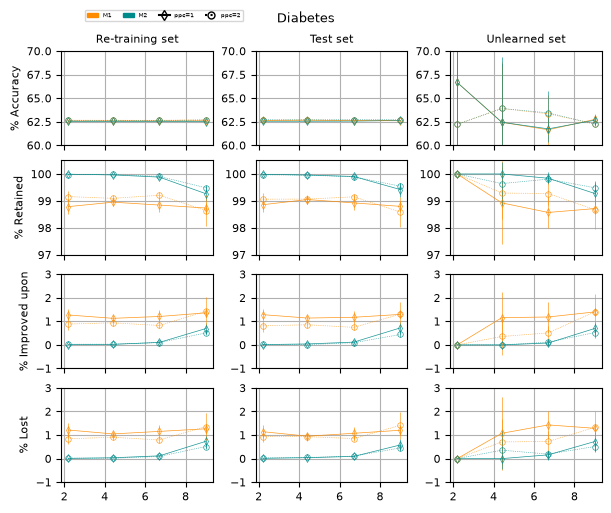

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
fs, lw,ms, mew=8, 0.5, 4, 0.5
lcolor, mfc, alpha=['r','g','b'], ['none',''], [1, 0.75, 0.6]
panel_col_dict={'tr': 'Re-training set', 'te': 'Test set', 'un': 'Unlearned set'}
vert_panel_col_dict={'retain frac': '% Retained', 'loss frac': '% Lost', 'gain frac': '% Improved upon',
                    'Acc':'% Accuracy'}
dname_ylims={'breastcancer':{'Acc':[55,101], 'retain frac':[50,101], 'gain frac': [-0.5,6],
                        'loss frac': [-1,50]},
            'surgical':{'Acc':[60,90.5],'retain frac':[70,100.5], 'gain frac': [-1,25],
                     'loss frac': [-1,25]},
            'banking':{'Acc':[85,95.5],'retain frac':[95,100.5], 'gain frac': [-0.5,2],
                    'loss frac': [-1, 4]},
            'adult':{'Acc':[65,90], 'retain frac':[95,100.5],'gain frac': [-5,30],
                      'loss frac': [-0.5,5]},
             'diabetes':{'Acc':[60,70], 'retain frac':[97,100.5], 'gain frac': [-1,3],
                        'loss frac': [-1,3]},
             'criteo':{'Acc':[94,1001],'retain frac': [99.4,100.2],'gain frac':[-5,5],
                      'loss frac': [-0.05,0.05]},  
            }
combined['ppc']=combined['ppc'].astype(int)
fig0, ax0= plt.subplots(nrows=4, ncols=3, sharex=True, figsize=(6,5), layout="constrained")
marker=['d','o','s']
linestyle, lcolor=['solid','dotted'],['darkorange','darkcyan']
alpha=[0.9, 0.85]
print_table={}
for i in np.sort(combined['ppc'].unique()):
    dummy_df=combined.loc[(combined['ppc']==i)].copy()
    ext_tab={}
    m, ls=marker[i-1], linestyle[i-1]
    for sidx, subset in enumerate(['tr','te','un']):
        c, ylabel=1,panel_col_dict[subset]
        measures=['n_unlearned', 'mean_%s_Acc_M1'%(subset), 'std_%s_Acc_M1'%(subset),
                  'mean_%s_retain_frac_M1'%(subset), 'std_%s_retain_frac_M1'%(subset),
                  'mean_%s_gain_frac_M1'%(subset), 'std_%s_gain_frac_M1'%(subset),
                  'mean_%s_loss_frac_M1'%(subset), 'std_%s_loss_frac_M1'%(subset),
                  'mean_%s_Acc_M2'%(subset), 'std_%s_Acc_M2'%(subset),
                  'mean_%s_retain_frac_M2'%(subset), 'std_%s_retain_frac_M2'%(subset),
                  'mean_%s_gain_frac_M2'%(subset), 'std_%s_gain_frac_M2'%(subset),
                  'mean_%s_loss_frac_M2'%(subset), 'std_%s_loss_frac_M2'%(subset),
                  ]
        temp_df=dummy_df[measures].copy()
        Mtype=np.concatenate([np.full((1,temp_df['n_unlearned'].nunique()), 'M1'),
               np.full((1,temp_df['n_unlearned'].nunique()), 'M2')], axis=1)[0]
        df_reorient=pd.DataFrame(data=np.concatenate([temp_df[measures[1:9]].to_numpy(), temp_df[measures[9:]].to_numpy()]),
                         columns=['_'.join([x.split('_')[0], '_'.join(x.split('_')[2:-1])]) for x in measures[1:9]])
        df_reorient.insert(0, 'n_unlearned', np.concatenate([temp_df['n_unlearned'].to_numpy(),temp_df['n_unlearned'].to_numpy()]))
        df_reorient.insert(0, 'Model', Mtype)
        df_reorient.insert(0, 'subset', np.full((1,2*temp_df['n_unlearned'].nunique()), subset)[0])
        df_reorient.insert(0, 'ppc', np.full((1,2*temp_df['n_unlearned'].nunique()), i)[0])
        ext_tab[subset]=df_reorient.copy()
        for midx, model in enumerate(['M1', 'M2']):#  print(subset, model, i)
            lc=lcolor[midx]
            for nrow in [0,1,2,3]:
                colname_parts=measures[c].split('_')[2:-1]
                if (nrow==0):# & (sidx==0):        
                    ylabel=colname_parts[0]
                    c_ylim=dname_ylims[dname][ylabel]
                if (nrow>0):
                    ylabel=' '.join(colname_parts)
                    c_ylim=dname_ylims[dname][ylabel]
                if dname=='criteo':
                    ax0[nrow, sidx].errorbar(np.log(temp_df['n_unlearned']), temp_df[measures[c]], yerr=temp_df[measures[c+1]], 
                                color=lc, marker=m, ls=ls,mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',
                                              label='%s: %d ppc'%(model,i), alpha=alpha[i-1])
                else:
                    ax0[nrow, sidx].errorbar(np.log(temp_df['n_unlearned']), temp_df[measures[c]], yerr=temp_df[measures[c+1]], 
                                color=lc, marker=m, ls=ls,mew=mew, lw=lw, ms=ms, mec=lc,mfc='none',
                                              label='%s: %d ppc'%(model,i), alpha=alpha[i-1]) 
                ax0[nrow,sidx].set_ylim(c_ylim)
                ax0[nrow, sidx].tick_params(axis='both', which='both', labelsize=fs)  
                if c in [1, 3, 9,11]:
                    steps=2.5
                else:
                    steps=1
                if (i==1) & (midx==0):
                    ax0[nrow, sidx].grid()
                if nrow==0:
                    if (i==1) & (midx==0):
                        ax0[nrow,sidx].set_title(panel_col_dict[subset], fontsize=fs)
                if midx==0:                    
                    ax0[nrow,0].set_ylabel(vert_panel_col_dict[ylabel], fontsize=fs)                 
                c+=2
    print_table[i]=ext_tab.copy()
    del ext_tab
handles, labels = ax0[0,0].get_legend_handles_labels()
patch1,patch2 = mpatches.Patch(color=lcolor[0], label='M1'), mpatches.Patch(color=lcolor[1], label='M2')
P1_line = mlines.Line2D([], [], color='k', marker=marker[0], mfc='none', mec='k', markersize=ms+1, linestyle=linestyle[0],label='ppc=1')
P2_line = mlines.Line2D([], [], color='k', marker=marker[1], mfc='none', mec='k', markersize=ms+1, linestyle=linestyle[1],label='ppc=2')
handleorder1, handleorder2=[patch1, patch2, P1_line, P2_line], [patch1, P1_line, patch2, P2_line]
#fig0.legend(handles, labels, loc='lower center', ncols=6, prop={"size":8})
if dname=='criteo':
    fig0.legend(handles=handleorder2, loc='lower right', ncols=3, prop={"size":5},
           bbox_to_anchor=(0.5, 0))
else:
    fig0.legend(handles=handleorder1, loc='upper right', ncols=4, prop={"size":4},
           bbox_to_anchor=(0.4, 1))
fig0.suptitle(dname.capitalize(), fontsize=fs+1)
fig0.savefig('%sperf_enforced_swish_wrt_M0_%s_%s.pdf'%(figpath, dname, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

In [9]:
print(print_table[i]['tr'].shape)
print_table[i]['tr']
consolidated=pd.concat([print_table[1]['tr'],print_table[1]['te'],print_table[1]['un'],
                       print_table[2]['tr'],print_table[2]['te'],print_table[2]['un']], axis=0, ignore_index=True)
consolidated['subset']=consolidated['subset'].map({'tr':'retraining', 'te':'test', 'un':'unlearned'})
consolidated.sort_values(by=['ppc', 'Model', 'n_unlearned','subset'], inplace=True)
consolidated[consolidated.columns[3:]]=consolidated[consolidated.columns[3:]].round(2)
#print(prot_df.shape, prot_df2.shape)
print(consolidated.shape)
cons_cols=np.unique(['_'.join(x.split('_')[1:]) for x in consolidated.columns[4:]])
print(cons_cols)
for col in cons_cols:
    consolidated[col]=consolidated['mean_'+col].astype(str)+' ('+consolidated['std_'+col].astype(str)+')'
    
print_cols=consolidated[list(consolidated.columns[:4])+list(cons_cols)]
all_cols=print_cols.columns
for idx, col in enumerate(all_cols):
    if idx<len(all_cols)-1:
        print_cols.insert(np.where(print_cols.columns==col)[0][0]+1, 'amp-'+str(idx+1),
                  np.full((1,print_cols.shape[0]), '&')[0])
    else:
        print_cols.insert(np.where(print_cols.columns==col)[0][0]+1, ' -',
                  np.full((1,print_cols.shape[0]), '\\ \\')[0])
print_cols.sort_values(by=['ppc','n_unlearned','Model'], inplace=True)
print_cols.to_csv('%sprint_perf/%s_enforced_random_sgd_swish.csv'%(out_path,dname), sep='\t', index=False)
print_cols.to_csv('%sprint_perf/%s_enforced_random_sgd_swish.txt'%(out_path,dname), sep='\t', index=False)
print_cols.loc[print_cols['ppc']==1]

(8, 12)
(48, 12)
['Acc' 'gain_frac' 'loss_frac' 'retain_frac']


,ppc,amp-1,subset,amp-2,Model,amp-3,n_unlearned,amp-4,Acc,amp-5,gain_frac,amp-6,loss_frac,amp-7,retain_frac,-
0,1,&,retraining,&,M1,&,9.0,&,62.58 (0.06),&,1.27 (0.23),&,1.21 (0.28),&,98.79 (0.28),\ \
8,1,&,test,&,M1,&,9.0,&,62.64 (0.04),&,1.28 (0.24),&,1.14 (0.27),&,98.86 (0.27),\ \
16,1,&,unlearned,&,M1,&,9.0,&,66.67 (23.57),&,0.0 (0.0),&,0.0 (0.0),&,100.0 (0.0),\ \
4,1,&,retraining,&,M2,&,9.0,&,62.54 (0.0),&,0.01 (0.01),&,0.01 (0.0),&,99.99 (0.0),\ \
12,1,&,test,&,M2,&,9.0,&,62.55 (0.01),&,0.01 (0.01),&,0.01 (0.01),&,99.99 (0.01),\ \
20,1,&,unlearned,&,M2,&,9.0,&,66.67 (23.57),&,0.0 (0.0),&,0.0 (0.0),&,100.0 (0.0),\ \
1,1,&,retraining,&,M1,&,82.0,&,62.59 (0.03),&,1.13 (0.15),&,1.05 (0.14),&,98.95 (0.14),\ \
9,1,&,test,&,M1,&,82.0,&,62.67 (0.06),&,1.14 (0.12),&,0.95 (0.15),&,99.05 (0.15),\ \
17,1,&,unlearned,&,M1,&,82.0,&,62.44 (6.42),&,1.16 (1.07),&,1.07 (1.54),&,98.93 (1.54),\ \
5,1,&,retraining,&,M2,&,82.0,&,62.53 (0.01),&,0.02 (0.01),&,0.04 (0.01),&,99.96 (0.01),\ \


In [10]:
import sklvq
from experiment_utils import dataset_health
from experiment_utils import data_norm_log
from unlearning.unlearn_eval import *
modelpath='/'.join(parts)+'/models/'
from collections import Counter
#dname, solver_type='breastcancer', 'sgd'
nprots_per_class=1
picklefilename='%s%s/%s_random_enforced_swish_%s_nprot%d.pkl'%(modelpath, dname, dname, solver_type, nprots_per_class)
with open(picklefilename, 'rb') as file:
    model_sets=pickle.load(file)
retrained_all, unlearned_all=model_sets['retrained'], model_sets['unlearned']
M0=model_sets['original']
Xtrain, Ytrain, Xtest, Ytest, features=dataset_health(dname)
zXtrain, zXtest=data_norm_log(Xtrain, Xtest)
nopts, iter=2, 2
M1, M2=retrained_all[nopts]['models'][iter]['model'], unlearned_all[nopts]['models'][iter]['model']
print(list(unlearned_all.keys()))
n=unlearned_all[nopts]['n']
print(n, unlearned_all[nopts]['n'])
unlearn_indices=unlearned_all[nopts]['models'][iter]['unlearn_indices']
enforced_indices=unlearned_all[nopts]['models'][iter]['enforced_indices']
zXunlearn, Yunlearn=zXtrain.iloc[unlearn_indices], Ytrain[unlearn_indices]
est_unlearn_M0, est_unlearn_M1, est_unlearn_M2=M0.predict(zXunlearn), M1.predict(zXunlearn), M2.predict(zXunlearn)
print(Counter(Ytrain[unlearn_indices]), Counter(Ytrain[enforced_indices]))
idx=0
if nprots_per_class==1:
    prot_group_dummy=pd.DataFrame(data=np.array([Xtrain.columns,
                    np.exp(M0.prototypes_[idx]).T,   np.exp(M1.prototypes_[idx]).T,   np.exp(M2.prototypes_[idx]).T,
                    np.exp(M0.prototypes_[idx+1]).T, np.exp(M1.prototypes_[idx+1]).T, np.exp(M2.prototypes_[idx+1]).T]).T,
                           columns=['features','M0-0','M1-0', 'M2-0','M0-1','M1-1', 'M2-1'])
else:
    prot_group_dummy=pd.DataFrame(data=np.array([Xtrain.columns,
                    np.exp(M0.prototypes_[idx]).T,   np.exp(M1.prototypes_[idx]).T,   np.exp(M2.prototypes_[idx]).T,
                    np.exp(M0.prototypes_[idx+1]).T, np.exp(M1.prototypes_[idx+1]).T, np.exp(M2.prototypes_[idx+1]).T,
                    np.exp(M0.prototypes_[idx+2]).T, np.exp(M1.prototypes_[idx+2]).T, np.exp(M2.prototypes_[idx+2]).T,  
                    np.exp(M0.prototypes_[idx+3]).T, np.exp(M1.prototypes_[idx+3]).T, np.exp(M2.prototypes_[idx+3]).T,
                                                ]).T,
                           columns=['features','M0-00','M1-00', 'M2-00','M0-01','M1-01', 'M2-01',
                                   'M0-10','M1-10', 'M2-10','M0-11','M1-11', 'M2-11'])
#prot_group_dummy=prot_group_dummy.transform([np.exp])
prot_group_dummy['Median-%d'%idx]=Xtrain.loc[Ytrain==idx].median().to_numpy()
prot_group_dummy['Mean-%d'%idx]=Xtrain.loc[Ytrain==idx].mean().to_numpy()
idx=idx+1
prot_group_dummy['Median-%d'%idx]=Xtrain.loc[Ytrain==idx].median().to_numpy()
prot_group_dummy['Mean-%d'%idx]=Xtrain.loc[Ytrain==idx].mean().to_numpy()
if nprots_per_class==1:
    temp_dummy=prot_group_dummy[['features','M0-0','M1-0', 'M2-0', 'Median-0', 'Mean-0','M0-1','M1-1', 'M2-1', 'Median-1', 'Mean-1']]
else:
    temp_dummy=prot_group_dummy[['features','M0-00','M1-00', 'M2-00','M0-01','M1-01', 'M2-01', 'Median-0', 'Mean-0',
                      'M0-10','M1-10', 'M2-10','M0-11','M1-11', 'M2-11', 'Median-1', 'Mean-1']]
temp_dummy

[0, 1, 2, 3]
815 815
Counter({0: 446, 1: 369}) Counter({0: 446, 1: 369})


,features,M0-0,M1-0,M2-0,Median-0,Mean-0,M0-1,M1-1,M2-1,Median-1,Mean-1
0,num_gender,0.007211,0.006951,0.007193,0.00,0.471625,0.006626,0.00683,0.006602,0.00,0.452213
1,num_change,0.006916,0.006819,0.006937,0.00,0.441155,0.007534,0.00769,0.007528,0.00,0.487600
2,num_diabetesMed,0.098342,0.098637,0.098671,1.00,0.745104,0.14996,0.15025,0.149988,1.00,0.797280
3,time_in_hospital,2.516594,2.528759,2.517108,3.00,4.260293,5.579325,5.558987,5.576885,4.00,4.566880
4,num_lab_procedures,28.967544,28.858442,28.962627,43.00,42.368783,45.856188,46.539296,45.85966,45.00,43.908133
5,num_procedures,0.021537,0.021798,0.021566,1.00,1.409888,0.018511,0.01825,0.018574,1.00,1.254053
6,num_medications,9.993799,10.017507,9.997319,14.00,15.662051,22.77689,22.862062,22.782727,15.00,16.413840
7,number_outpatient,0.000472,0.000469,0.000471,0.00,0.271156,0.000745,0.000743,0.000744,0.00,0.481653
8,number_emergency,0.000244,0.000246,0.000244,0.00,0.110676,0.000548,0.000542,0.000548,0.00,0.302107
9,number_inpatient,0.0021,0.002094,0.002102,0.00,0.381376,0.005339,0.005309,0.00533,0.00,0.934427


[-4.93037777 -4.97608798 -2.31861771  0.92314069  3.36598369 -3.84002708
  2.30213784 -7.65856232 -8.31972727 -6.1652557   1.39453505 -9.25799894
 -9.21291138  3.87041377 -9.2072528  -9.21038124 -9.21036564 -8.69947317
 -9.21261003 -8.12674262 -9.21537054 -8.23650855 -9.11599803 -4.69363659
 -7.40918091 -9.20863115 -9.20584729 -9.21938985 -9.12445398 -8.5491801
 -9.12387673 -8.64565676 -9.20001367 -9.19009584 -9.21307731 -7.66201945
 -2.91101698 -9.2743033  -9.03941721 -7.95462583 -7.541336   -2.64978993
 -8.83561173]
[-4.93253059 -4.97374871 -2.31947159  0.9230433   3.36615615 -3.83771459
  2.30206032 -7.65822264 -8.31928542 -6.1658676   1.39441648 -9.2580078
 -9.21291186  3.87034104 -9.20725223 -9.21038125 -9.21036565 -8.69937815
 -9.21261045 -8.12685178 -9.21537147 -8.23656189 -9.11598049 -4.69433058
 -7.40897974 -9.20863083 -9.20584646 -9.21939154 -9.124438   -8.54862039
 -9.12369398 -8.64564285 -9.20001175 -9.19009208 -9.21307782 -7.66030051
 -2.91286191 -9.27441107 -9.039417   -7

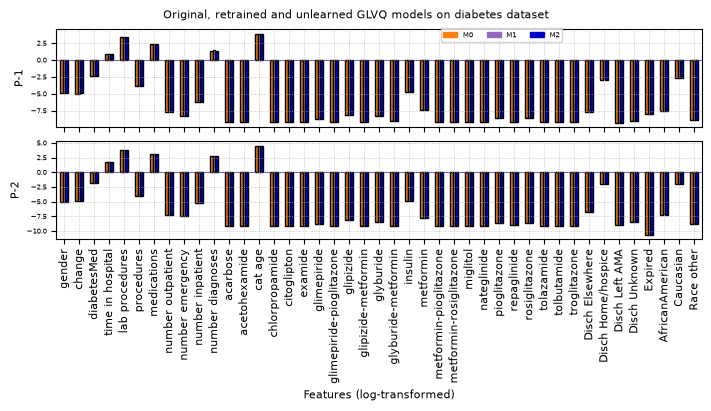

In [11]:
iter=0
print(unlearned_all[0]['models'][iter]['model'].prototypes_[0])
iter=1
print(unlearned_all[0]['models'][iter]['model'].prototypes_[0])
relearn_indices=retrained_all[nopts]['models'][iter]['retrain_indices']

fig5, ax5= plt.subplots(nrows=M0.prototypes_.shape[0],figsize=(7,4), dpi=100, layout="constrained", sharex=True)
ylims=[np.ceil(np.min(M0.prototypes_))-1, np.ceil(np.max(M0.prototypes_))]
xticklabels=["" for x in range(len(Xtrain.columns))]
for i, term in enumerate(Xtrain.columns):
    temp=term.split('_')
    if temp[0]=='num':
        xticklabels[i]=' '.join(temp[1:])
    else:
        xticklabels[i]=' '.join(temp)
for i in range(0, M0.prototypes_.shape[0]):
    prot_group=pd.DataFrame(data=np.array([Xtrain.columns,M0.prototypes_[i].T, M1.prototypes_[i].T, M2.prototypes_[i].T]).T,
                           columns=['features','M0','M1', 'M2'])#features)
    prot_group.set_index("features", inplace=True)
    prot_group[['M0','M1', 'M2']]=prot_group[['M0','M1', 'M2']].astype('float64')#.transform(np.exp)
    #prot_group[['M0','M1', 'M2']]=(prot_group[['M0','M1', 'M2']]-prot_group[['M0','M1', 'M2']].mean())/prot_group[['M0','M1', 'M2']].std()
    prot_group.plot.bar(ax=ax5[i], color=['tab:orange', 'tab:purple','mediumblue'], edgecolor=['k','k','k'])
    ax5[i].axhline(y=0.0, c="blue",linewidth=0.5,zorder=0)
    ax5[i].set_ylabel('P-%d'%(i+1), fontsize=fs)
    ax5[i].set_xticklabels(xticklabels, fontsize=fs)
    ax5[i].tick_params(axis='both', which='minor', labelsize=fs-3)
    ax5[i].yaxis.set_tick_params(labelsize=fs-3)
    ax5[i].get_legend().remove()
   # ax5[i].set_ylim(ylims)
#ax5[1].get_legend().remove()
    ax5[i].grid(which='both', linestyle = ':', linewidth = 0.5)
#ax5[1].grid(linestyle = ':', linewidth = 0.5)
ax5[i].set_xlabel('Features (log-transformed)', fontsize=fs)
patch1,patch2 = mpatches.Patch(color='tab:orange', label='M0'), mpatches.Patch(color='tab:purple', label='M1')
patch3=mpatches.Patch(color='mediumblue', label='M2')
handleorder1=[patch1, patch2, patch3]
if nprots_per_class==1:
    fig5.legend(handles=handleorder1, loc='lower right', ncols=5, prop={"size":5},
           bbox_to_anchor=(0.8, 0.9))
else:
    fig5.legend(handles=handleorder1, loc='lower right', ncols=5, prop={"size":5},
           bbox_to_anchor=(0.9, 0.05))
fig5.suptitle('Original, retrained and unlearned GLVQ models on %s dataset'%dname, fontsize=fs)
fig5.savefig('%s%s_enforced_devProtsM0M1M2_swish_%s_nprot%d.pdf'%(figpath,dname, solver_type, nprots_per_class), dpi=100, bbox_inches="tight", pad_inches=0.01)
#prot_group

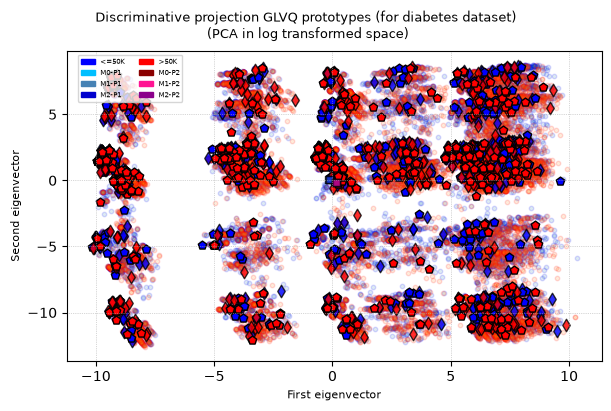

In [13]:
from sklearn.decomposition import PCA
i=0
if nprots_per_class==1:
    prot_group2=pd.DataFrame(data=np.array([M0.prototypes_[i], M1.prototypes_[i], M2.prototypes_[i]]), 
                           columns=Xtrain.columns)
    prot_group3=pd.DataFrame(data=np.array([M0.prototypes_[i+1], M1.prototypes_[i+1], M2.prototypes_[i+1]]), 
                           columns=Xtrain.columns)
else:
    prot_group2=pd.DataFrame(data=np.array([M0.prototypes_[i], M1.prototypes_[i], M2.prototypes_[i]]), 
                           columns=Xtrain.columns)
    prot_group3=pd.DataFrame(data=np.array([M0.prototypes_[i+2], M1.prototypes_[i+2], M2.prototypes_[i+2]]), 
                           columns=Xtrain.columns)
pca_X=PCA(n_components='mle', svd_solver="full").fit(zXtrain.iloc[relearn_indices])
pc_prots_df1, pc_prots_df2=pca_X.transform(prot_group2),pca_X.transform(prot_group3)
pc_retrain_df=pca_X.transform(zXtrain.iloc[relearn_indices])
pc_unlearn_df=pca_X.transform(zXtrain.iloc[unlearn_indices])
pc_enforce_df=pca_X.transform(zXtrain.iloc[enforced_indices])
labels=Ytrain[relearn_indices]#[unlearn_indices]
un_labels=Ytrain[unlearn_indices]#[unlearn_indices]
en_labels=Ytrain[enforced_indices]
x_m1,y_m1,x_m2,y_m2 =pc_prots_df1[:, 0], pc_prots_df1[:, 1], pc_prots_df2[:, 0], pc_prots_df2[:, 1]
x_d , y_d,ux_d , uy_d= pc_retrain_df[:, 0], pc_retrain_df[:, 1], pc_unlearn_df[:, 0], pc_unlearn_df[:, 1]
ex_d , ey_d=pc_enforce_df[:, 0], pc_enforce_df[:, 1]
# Plot
fig, ax= plt.subplots(nrows=1,figsize=(6,4), dpi=100, layout="constrained")
fig.suptitle("Discriminative projection GLVQ prototypes (for %s dataset)\n (PCA in log transformed space)"%dname, fontsize=fs+1)
colors, colors2, colors3 = ["blue", "red"],['deepskyblue','steelblue','mediumblue'],['darkred','deeppink','darkmagenta']
lab_val=['<=50K', '>50K']

for i, cls in enumerate(M0.classes_):
##    print(i, cls)
    ii = cls == labels
    scatter=ax.scatter(x_d[ii],y_d[ii],marker='o',c=None,alpha=0.15,s=10,edgecolors=colors[i],
               label=lab_val[i])
for i, cls in enumerate(M0.classes_):
    ii = cls == un_labels
    scat1=ax.scatter(ux_d[ii],uy_d[ii],c=colors[i],marker='d', s=40,edgecolors="k",
               label=lab_val[i], alpha=0.8)
    ii = cls == en_labels
    scat1=ax.scatter(ex_d[ii],ey_d[ii],c=colors[i],marker='p', s=40,edgecolors="k",
               label=lab_val[i])

scat2=ax.scatter(x_m1, y_m1, c=colors2, marker='s', s=30, alpha=[1,0.8, 0.6], edgecolors="black", linewidth=1.0, label=['M0-P1','M1-P1','M2-P1'])
scat3=ax.scatter(x_m2, y_m2, c=colors3,marker='s', s=30, alpha=[1,0.8, 0.6], edgecolors="black", linewidth=1.0,
                label=['M0-P2','M1-P2','M2-P2'])
ax.set_xlabel("First eigenvector", fontsize=fs)
ax.set_ylabel("Second eigenvector", fontsize=fs)
ax.grid(linestyle = ':', linewidth = 0.5)
patch1,patch2 = mpatches.Patch(color='b', label='<=50K'), mpatches.Patch(color='r', label='>50K')
patch3,patch4 = mpatches.Patch(color=colors2[0], label='M0-P1'), mpatches.Patch(color=colors3[0], label='M0-P2')
patch5,patch6 = mpatches.Patch(color=colors2[1], label='M1-P1'), mpatches.Patch(color=colors3[1], label='M1-P2')
patch7,patch8 = mpatches.Patch(color=colors2[2], label='M2-P1'), mpatches.Patch(color=colors3[2], label='M2-P2')
handleorder1=[patch1, patch3, patch5, patch7, patch2, patch4, patch6, patch8]
if dname=='adult':
    fig.legend(handles=handleorder1, loc='lower right', ncols=2, prop={"size":5},
           bbox_to_anchor=(0.8, 0.1))
else:
    fig.legend(handles=handleorder1, loc='lower right', ncols=2, prop={"size":5},
           bbox_to_anchor=(0.3, 0.75))
fig.savefig('%s%s_Df_enforced_ProtsM0M1M2_swish_%s_nprot%d.pdf'%(figpath, dname, solver_type, nprots_per_class),
            dpi=100, bbox_inches="tight", pad_inches=0.01)
del x_d , y_d, x_m1,y_m1, x_m2,y_m2,pc_retrain_df
ax.grid(True)

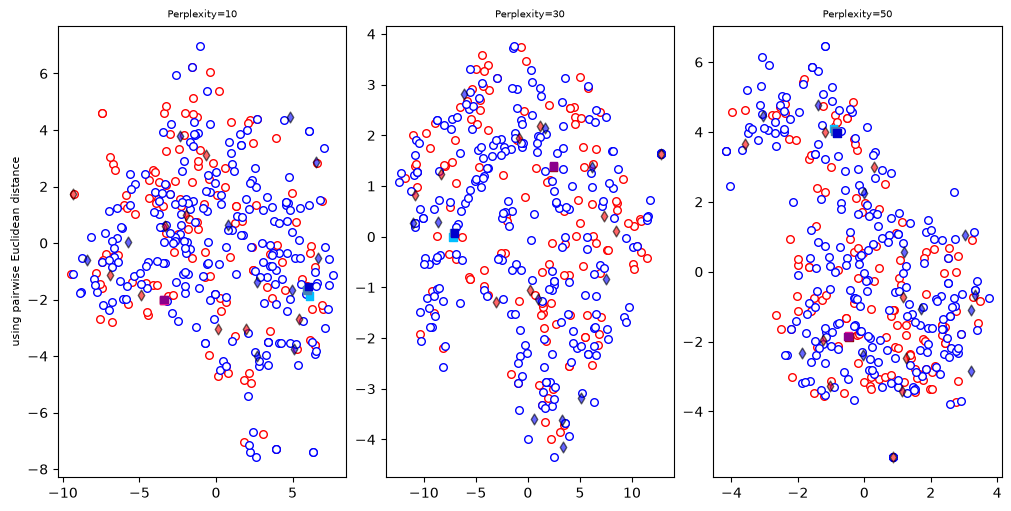

In [12]:
sys.path.append('/'.join(parts[:5])+'/common_utils/')
from partial_data_TSNE import *
from scipy.spatial.distance import pdist
from sklearn.metrics.pairwise import pairwise_distances, nan_euclidean_distances, euclidean_distances
from sklearn.manifold import TSNE

all_entities=np.concatenate([zXtrain.iloc[relearn_indices].to_numpy(), zXtrain.iloc[unlearn_indices].to_numpy(),
        M0.prototypes_,M1.prototypes_,M2.prototypes_],#M0.prototypes_[1],M1.prototypes_[1],M2.prototypes_[1]], 
                            axis=0)
#pd_train_00=pairwise_distances(all_entities, metric='cosine')
#pd_train_00=pairwise_distances(all_entities, metric='euclidean')
pd_train_00=euclidean_distances(all_entities,all_entities)
ncomp=3
fs, ms, marker,s=8, 5, 'o', 30
p_choices=[10,30,50]
if dname=='breastcancer':
#figdict['fontsize'], figdict['markersize'], figdict['marker'], figdict['markersize']
    fig_eda1, ax_eda1=plt.subplots(1,len(p_choices), figsize=(10,5), layout='constrained')
    for idx in range(0,len(p_choices)):
        pd_embedded=TSNE(n_components=ncomp,learning_rate='auto',metric='precomputed',init='random', 
                     perplexity=p_choices[idx]).fit_transform(pd_train_00)
        pd_embedded_unlearn=pd_embedded[:len(unlearn_indices),:].copy()
        pd_embedded_relearn=pd_embedded[len(unlearn_indices):len(unlearn_indices)+len(relearn_indices),:].copy()
        prots_indx_start=len(unlearn_indices)+len(relearn_indices)
        pd_embedded_prots=pd_embedded[prots_indx_start:,:].copy()
        ax_eda1[idx].scatter(pd_embedded_relearn[Ytrain[relearn_indices]==0, 0], 
                               pd_embedded_relearn[Ytrain[relearn_indices]==0, 1], s=s, marker='o',c='white',edgecolors='r')
        ax_eda1[idx].scatter(pd_embedded_relearn[Ytrain[relearn_indices]==1, 0], 
                               pd_embedded_relearn[Ytrain[relearn_indices]==1, 1], s=s, marker='o',c='white',edgecolors='b')
        ax_eda1[idx].scatter(pd_embedded_unlearn[Ytrain[unlearn_indices]==0, 0], 
                               pd_embedded_unlearn[Ytrain[unlearn_indices]==0, 1], s=s, marker='d',alpha=0.6,
                              c='r',edgecolors='k')
        ax_eda1[idx].scatter(pd_embedded_unlearn[Ytrain[unlearn_indices]==1, 0], 
                               pd_embedded_unlearn[Ytrain[unlearn_indices]==1, 1], s=s, marker='d',alpha=0.6,
                              c='b',edgecolors='k')
        ax_eda1[idx].scatter(pd_embedded_prots[[0,2,4], 0], pd_embedded_prots[[0,2,4], 1], s=s, marker='s',c=colors2)
        ax_eda1[idx].scatter(pd_embedded_prots[[1,3,5], 0], pd_embedded_prots[[1,3,5], 1], s=s, marker='s',c=colors3)
       # pd_embedded=TSNE(n_components=ncomp,learning_rate='auto',metric='precomputed',init='random', 
       #              perplexity=p_choices[idx]).fit_transform(pd_train_2)
       # ax_eda1[1,idx].scatter(pd_embedded[:, 0], pd_embedded[:, 1], s=s, marker=marker)
        ax_eda1[idx].set_title('Perplexity=%d'%p_choices[idx], fontsize=fs-1)
        if idx==0:
            ax_eda1[idx].set_ylabel('using pairwise Euclidean distance', fontsize=fs)
        #    ax_eda1[1,idx].set_ylabel('using pairwise Cosine dissimilarity', fontsize=fs)

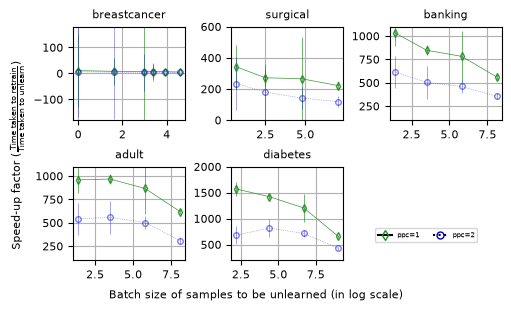

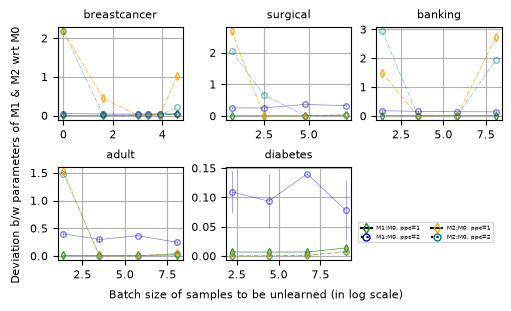

In [47]:

figpath='/'.join(parts)+'/figures/'
linestyle, lcolor=['solid','dotted'],['forestgreen','mediumblue']
lcolor2=['orange','teal']
alpha,marker=[0.9, 0.5],['d','o','s']
dname_all=['breastcancer', 'surgical', 'banking', 'adult', 'diabetes']
row_col_map={'breastcancer':[0,0],'surgical':[0,1],'banking':[0,2], 'adult':[1,0],'diabetes':[1,1]}
fs, lw, ms=8, 0.5, 4

dname_ylims={'breastcancer':[-180, 180],
            'surgical':[0,600],
             'banking':[100, 1100],
            'adult':[100, 1100],
              'diabetes':[200, 2000],
            }
figS, axS= plt.subplots(nrows=2, ncols=int((len(dname_all)+1)/2),figsize=(5,3), dpi=100, layout="constrained")
figD, axD= plt.subplots(nrows=2, ncols=int((len(dname_all)+1)/2),figsize=(5,3), dpi=100, layout="constrained")

eval_metrics=['speedupX','dev_M0M2','dev_M1M2','dev_M0M1']
for dname in dname_all:
    metapath='%s%s/%s_random_enforced_unlearn_swish_%s_all.csv'%(srcpath,dname, dname,solver_type)
    meta_df=pd.read_csv(metapath, sep='\t')
    meta_df.rename(columns={'n_unlearn':'n_unlearned'}, inplace=True)
    meta_df['speedupX']=meta_df['et_retrain'].to_numpy()/meta_df['et_unlearn'].to_numpy()
    mean_res=meta_df.groupby(['n_unlearned','ppc'])[eval_metrics].mean().reset_index()
    std_res=sliced_df.groupby(['n_unlearned','ppc'])[eval_metrics].std().reset_index()
    mean_cols=['mean_'+ entry for entry in eval_metrics]
    std_cols=['std_'+ entry for entry in eval_metrics]
    mean_res.rename(columns=dict(zip(eval_metrics, mean_cols)), inplace=True)
    std_res.rename(columns=dict(zip(eval_metrics, std_cols)), inplace=True)
    common_cols=list(np.intersect1d(list(mean_res.columns), list(std_res.columns)))    
    final_col_order=list(itertools.chain(*[ [mean_cols[i], std_cols[i]] for i in range(0, len(mean_cols))]))
    combined=pd.concat([mean_res, std_res[std_cols]], axis=1)
    combined=combined[common_cols+final_col_order]
    combined=combined.loc[~combined['ppc'].isnull()]
    combined['ppc']=combined['ppc'].astype(int)
    #col_order=np.array(['n_unlearned', 'ppc', 'speedupX','dev_M0M2','dev_M1M2', 
   # solver_meta_df=meta_df.loc[(meta_df['solver_type']==solver_type)]
    for i in np.sort(combined['ppc'].unique()):
       # print(dname, i)
        m, ls, p=marker[i-1], linestyle[i-1], i-1
        prot_meta_df=combined.loc[(combined['ppc']==i)]
        nrow, ncol=row_col_map[dname][0],row_col_map[dname][1] 
        h=axS[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_speedupX'].to_numpy(),
                yerr=prot_meta_df['std_speedupX'].to_numpy(), marker=m, mfc='none', mec=lcolor[p], linestyle=ls,
                lw=lw, ms=ms, ecolor=lcolor[p],c=lcolor[p], alpha=alpha[i-1],  label='nProt=%d'%i)
        h2=axD[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_dev_M0M1'].to_numpy(),
                yerr=prot_meta_df['std_dev_M0M1'].to_numpy(), marker=m, mfc='none', mec=lcolor[p], linestyle='solid',
                lw=lw, ms=ms, ecolor=lcolor[p],c=lcolor[p], alpha=alpha[i-1],  label='nProt=%d'%i)
        h3=axD[nrow, ncol].errorbar(np.log(prot_meta_df['n_unlearned'].to_numpy()), prot_meta_df['mean_dev_M0M2'].to_numpy(),
                yerr=prot_meta_df['std_dev_M0M2'].to_numpy(), marker=m, mfc='none', mec=lcolor2[p], linestyle='-.',
                lw=lw, ms=ms, ecolor=lcolor2[p],c=lcolor2[p], alpha=alpha[i-1],  label='nProt=%d'%i)
    axS[nrow, ncol].grid()
    axS[nrow, ncol].tick_params(axis='both', which='major', labelsize=fs)
    axS[nrow, ncol].set_title(dname, fontsize=fs)
    axS[nrow, ncol].set_ylim(dname_ylims[dname])
    axD[nrow, ncol].grid()
    axD[nrow, ncol].tick_params(axis='both', which='major', labelsize=fs)
    axD[nrow, ncol].set_title(dname, fontsize=fs)
    axS[nrow, ncol].set_ylim(dname_ylims[dname])
    del combined, prot_meta_df
axS[1,2].remove()
axD[1,2].remove()
P1_line = mlines.Line2D([], [], color='k', marker=marker[0], mfc='none', mec=lcolor[0], markersize=ms+1, linestyle=linestyle[0],label='ppc=1')
P2_line = mlines.Line2D([], [], color='k', marker=marker[1], mfc='none', mec=lcolor[1], markersize=ms+1, linestyle=linestyle[1],label='ppc=2')
P3_line = mlines.Line2D([], [], color='k', marker=marker[0], mfc='none', mec=lcolor2[0], markersize=ms+1, linestyle=linestyle[0],label='M2:M0, ppc=1')
P4_line = mlines.Line2D([], [], color='k', marker=marker[1], mfc='none', mec=lcolor2[1], markersize=ms+1, linestyle=linestyle[1],label='M2:M0, ppc=2')

handleorder1=[P1_line, P2_line]
figS.legend(handles=handleorder1, loc='lower right', ncols=5, prop={"size":5},
           bbox_to_anchor=(0.95, 0.2))
figS.supxlabel('Batch size of samples to be unlearned (in log scale)', fontsize=fs)
figS.supylabel(r'Speed-up factor ($\frac{\text{Time taken to retrain}}{\text{Time taken to unlearn}}$)', fontsize=fs)
figS.savefig('%sspeedup_enforced_swish%s.pdf'%(figpath, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

P1_line = mlines.Line2D([], [], color='k', marker=marker[0], mfc='none', mec=lcolor[0], markersize=ms+1, linestyle=linestyle[0],label='M1:M0, ppc=1')
P2_line = mlines.Line2D([], [], color='k', marker=marker[1], mfc='none', mec=lcolor[1], markersize=ms+1, linestyle=linestyle[1],label='M1:M0, ppc=2')

handleorder2=[P1_line, P2_line, P3_line, P4_line]
figD.legend(handles=handleorder2, loc='lower right', ncols=2, prop={"size":4},
           bbox_to_anchor=(0.98, 0.2))

figD.supxlabel('Batch size of samples to be unlearned (in log scale)', fontsize=fs)
figD.supylabel('Deviation b/w parameters of M1 & M2 wrt M0', fontsize=fs)
figD.savefig('%sdeviationM1M2_swish_enforced_%s.pdf'%(figpath, solver_type), dpi=100, bbox_inches="tight", pad_inches=0.01)

In [16]:
combined

,n_unlearned,ppc,mean_speedupX,std_speedupX,mean_dev_M0M2,std_dev_M0M2,mean_dev_M1M2,std_dev_M1M2,mean_dev_M0M1,std_dev_M0M1
0,4.0,1,1036.201941,141.827394,1.493265,0.000104,1.499007,0.001187,0.007799,0.001188
1,4.0,2,617.039907,172.649111,2.945868,0.000058,3.007313,0.035871,0.180782,0.035856
2,33.0,1,847.597793,52.565127,0.000731,0.000037,0.007633,0.000805,0.007524,0.000818
3,33.0,2,503.008171,179.874787,0.001086,0.000018,0.159526,0.046408,0.159465,0.046400
4,330.0,1,782.755200,270.766902,0.003386,0.000129,0.007890,0.000435,0.007863,0.000343
5,330.0,2,460.099052,70.360577,0.002977,0.000208,0.148970,0.001358,0.148562,0.001359
6,3295.0,1,563.002938,29.748901,2.736746,0.000500,2.738679,0.001195,0.014661,0.000908
7,3295.0,2,355.509008,34.376487,1.945762,0.000503,1.985271,0.051004,0.141067,0.051142


In [25]:
int((len(dname_all)+1)/2)

3